libaraies

In [25]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [26]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [27]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [28]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [29]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [30]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [31]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [32]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [33]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [34]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout or whole trial ie sniff_start = trial_start and sniff_end = trial_end.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 seconds corresponds to 12 Hz

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

In [35]:
def extract_agent_face_sniffs(df):
    """
    Filters BORIS dataframe for facial sniffing initiated by the social agent.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Updated filters
    agent_mask = df['Subject'].str.lower() == 'social_agent'
    sniff_mask = df['Behavior'].str.lower() == 'facial sniffing'

    return df[agent_mask & sniff_mask]


ONE SUBJECT 3.6 WORKED

In [36]:
agent_sniffs = extract_agent_face_sniffs(RI2_3_6_boris)
print(agent_sniffs[['Subject', 'Behavior', 'Start (s)', 'Stop (s)']])


          Subject         Behavior  Start (s)  Stop (s)
12   social_agent  facial sniffing     25.600    26.100
23   social_agent  facial sniffing     68.767    69.600
36   social_agent  facial sniffing     91.900    92.267
40   social_agent  facial sniffing    153.900   154.400
41   social_agent  facial sniffing    156.233   156.567
43   social_agent  facial sniffing    195.433   195.767
46   social_agent  facial sniffing    196.167   197.500
53   social_agent  facial sniffing    218.300   219.367
59   social_agent  facial sniffing    226.433   226.900
64   social_agent  facial sniffing    234.867   235.367
67   social_agent  facial sniffing    249.733   250.567
68   social_agent  facial sniffing    257.833   258.367
70   social_agent  facial sniffing    267.400   268.933
71   social_agent  facial sniffing    269.767   270.600
75   social_agent  facial sniffing    273.367   274.200
78   social_agent  facial sniffing    282.033   283.067
79   social_agent  facial sniffing    288.200   

RUN LOOP ON ALL SUBJECTS WORKS

In [37]:
all_agent_sniffs = []

for label, boris_df in ri1_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs(boris_df)
    agent_sniffs["Trial"] = label
    agent_sniffs["Group"] = "RI1"
    all_agent_sniffs.append(agent_sniffs)

for label, boris_df in ri2_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs(boris_df)
    agent_sniffs["Trial"] = label
    agent_sniffs["Group"] = "RI2"
    all_agent_sniffs.append(agent_sniffs)

combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)


In [38]:
combined_sniffs_df

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop,Trial,Group,Media file,Total length,FPS,Modifiers
0,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,12.069,12.862,0.793,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,350.0,373.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
1,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,86.207,87.414,1.207,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,2500.0,2535.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
2,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,88.034,88.828,0.794,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,2553.0,2576.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
3,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,107.724,108.483,0.759,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,3124.0,3146.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
4,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,183.724,184.621,0.897,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,5328.0,5354.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
5,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,200.517,200.966,0.449,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,5815.0,5828.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
6,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,217.172,217.655,0.483,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,6298.0,6312.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
7,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,229.897,230.655,0.758,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,6667.0,6689.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
8,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,243.793,244.310,0.517,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,7070.0,7085.0,NaN,NaN,NaN,NaN,RI1_3_6,RI

In [39]:
ri_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    sampling_rate = entry['sampling_rate']

    # Get full duration
    sniff_start = time[0]
    sniff_end = time[-1]

    # Compute respiration rate
    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=sampling_rate)

    # Get valence
    valence = 'RI1' if trial.startswith('RI1') else ('RI2' if trial.startswith('RI2') else 'Other')

    # Extract subject as 3.6 from RI1_3_6
    try:
        parts = trial.split('_')
        subject = f"{parts[1]}.{parts[2]}"
    except IndexError:
        subject = 'Unknown'

    ri_session_rates.append({
        'Trial': trial,
        'Valence': valence,
        'Subject': subject,
        'Respiration Rate (Hz)': rate
    })

# Convert to DataFrame
ri_session_df = pd.DataFrame(ri_session_rates)
print(ri_session_df.head())


     Trial Valence Subject  Respiration Rate (Hz)
0  RI1_3_6     RI1     3.6               7.270376
1  RI2_3_6     RI2     3.6               5.932787
2  RI1_4_7     RI1     4.7               7.564174
3  RI2_4_7     RI2     4.7               6.551133
4  RI1_2_3     RI1     2.3               7.285965


In [40]:
ri_session_df

,Trial,Valence,Subject,Respiration Rate (Hz)
0,RI1_3_6,RI1,3.6,7.270376
1,RI2_3_6,RI2,3.6,5.932787
2,RI1_4_7,RI1,4.7,7.564174
3,RI2_4_7,RI2,4.7,6.551133
4,RI1_2_3,RI1,2.3,7.285965
5,RI2_2_3,RI2,2.3,6.674327
6,RI1_4_8,RI1,4.8,7.410347
7,RI2_4_8,RI2,4.8,5.775575
8,RI1_1_1,RI1,1.1,7.433281
9,RI2_1_1,RI2,1.1,6.008697


Windows used:
#     - Baseline:  -1.5s to -0.5s before sniff_start
#     - Post-sniff: +0.5s to +1.5s after sniff_start

 # Define time windows
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)

In [43]:
def calculate_percent_change_resp_rate(signal, time, sniff_start, sampling_rate=100, plot=True,
                                      baseline_color='gray', sniff_color='orange', title=None):
    """
    Calculates % change in instantaneous respiration rate (Hz) around a sniff event.

    Windows used:
    - Baseline:  -5s to -1s before sniff_start (4 seconds)
    - During sniff: 0s to +0.5s after sniff_start (0.5 seconds)

    Args:
        signal (np.array): respiration signal array
        time (np.array): corresponding time array
        sniff_start (float): sniff event start time (seconds)
        sampling_rate (int): sampling rate of the signal (Hz)
        plot (bool): whether to plot the result
        baseline_color (color): color for baseline bar in plot
        sniff_color (color): color for sniff bar in plot
        title (str): custom title for the plot

    Returns:
        percent_change (float): % change in respiration rate during sniff vs baseline
        baseline_mean_rate (float): mean respiration rate during baseline window (Hz)
        sniff_mean_rate (float): mean respiration rate during sniff window (Hz)
    """
    # Define time windows
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)

    baseline_segment = signal[baseline_mask]
    sniff_segment = signal[sniff_mask]

    min_distance_samples = int(0.0833 * sampling_rate)  # Min 75 ms between breaths

    # Detect peaks (breaths) in baseline and sniff windows
    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance_samples)
    sniff_peaks, _ = find_peaks(sniff_segment, distance=min_distance_samples)

    # Convert indices to actual time values for peaks
    baseline_peak_times = time[baseline_mask][baseline_peaks]
    sniff_peak_times = time[sniff_mask][sniff_peaks]

    # Calculate IBIs (time between peaks)
    baseline_ibis = np.diff(baseline_peak_times)
    sniff_ibis = np.diff(sniff_peak_times)

    if len(baseline_ibis) == 0 or len(sniff_ibis) == 0:
        if plot:
            print("Not enough peaks detected to calculate respiration rate change.")
        return None, None, None  # Not enough peaks to calculate

    # Instantaneous respiration rates (Hz) = 1 / IBI (seconds)
    baseline_rates = 1 / baseline_ibis
    sniff_rates = 1 / sniff_ibis

    # Calculate mean rates for baseline and sniff
    baseline_mean_rate = np.mean(baseline_rates)
    sniff_mean_rate = np.mean(sniff_rates)

    # Calculate percent change in respiration rate
    percent_change = ((sniff_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100

    if plot:
        plt.figure(figsize=(5, 4))
        plt.bar(['Baseline', 'During Sniff'], [baseline_mean_rate, sniff_mean_rate],
                color=[baseline_color, sniff_color])
        plt.ylabel('Respiration Rate (Hz)')
        if title is not None:
            plt.title(title)
        else:
            plt.title(f'Respiration Rate Change\n% Change: {percent_change:.2f}%')
        plt.show()

    return percent_change, baseline_mean_rate, sniff_mean_rate


In [44]:
results = []

for i, sniff_row in combined_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    # Get resp data for this trial
    resp_entry = resp_data.get(trial, None)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    percent_change, baseline_rate, post_rate = calculate_percent_change_resp_rate(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    if percent_change is None:
        print(f"Not enough peaks detected for sniff at {sniff_start}s in trial {trial}, skipping...")
        continue

    results.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Percent Change": percent_change,
        "Baseline Rate": baseline_rate,
        "Post-sniff Rate": post_rate
    })

results_df = pd.DataFrame(results)
print(results_df.head())

Not enough peaks detected for sniff at 153.9s in trial RI2_3_6, skipping...
Not enough peaks detected for sniff at 224.267s in trial RI2_4_8, skipping...
Not enough peaks detected for sniff at 488.333s in trial RI2_4_8, skipping...
Not enough peaks detected for sniff at 496.633s in trial RI2_4_8, skipping...
     Trial  Sniff Start  Percent Change  Baseline Rate  Post-sniff Rate
0  RI1_3_6       12.069       40.676642       8.293251        11.666667
1  RI1_3_6       86.207       10.004107       9.343085        10.277778
2  RI1_3_6       88.034        0.916251       9.058416         9.141414
3  RI1_3_6      107.724      -11.677579      10.064136         8.888889
4  RI1_3_6      183.724       10.348498       8.585148         9.473582


In [1]:
results_df


NameError: name 'results_df' is not defined

C:\Users\sjs93\AppData\Local\Temp\ipykernel_33908\1924890712.py:45: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


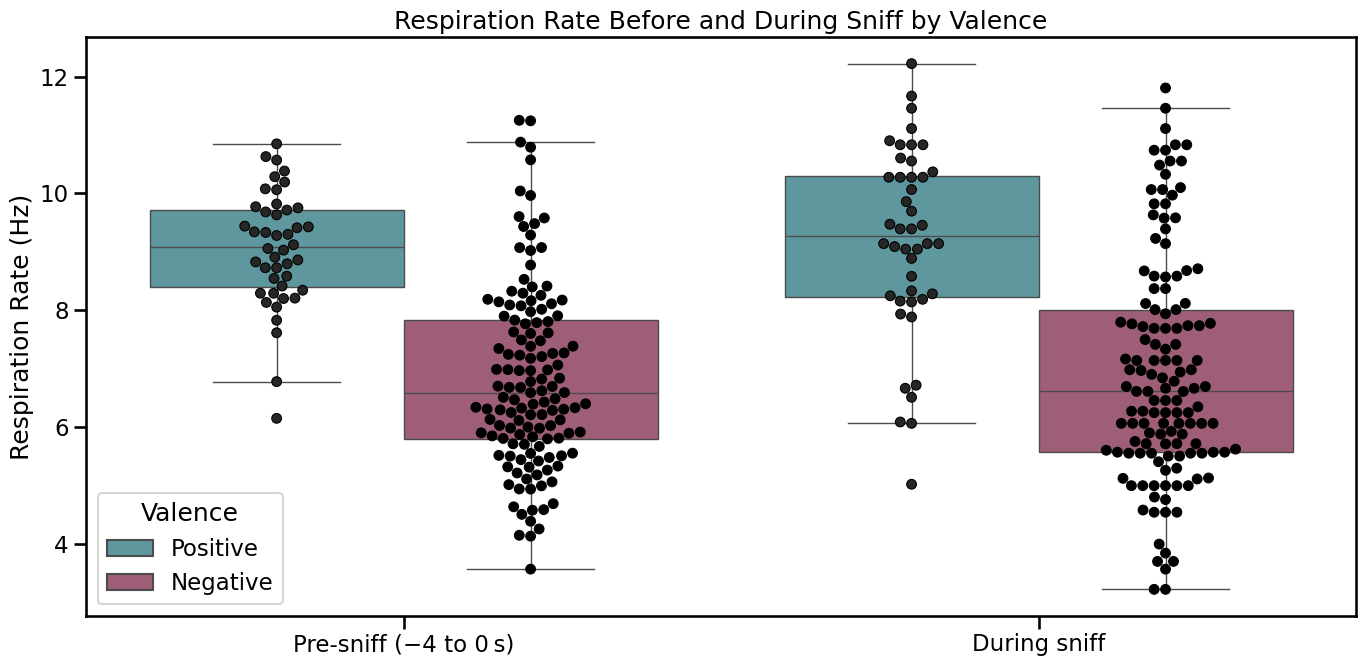

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette for positive and negative valence
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Add 'Valence' column based on 'Trial' string
results_df['Valence'] = results_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
results_df = results_df[results_df['Valence'] != 'Unknown']

# Melt dataframe for plotting
plot_df = results_df.melt(
    id_vars=["Trial", "Valence"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename conditions for clarity
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−4 to 0 s)",
    "Post-sniff Rate": "During sniff"
})

# Set up plot
plt.figure(figsize=(14, 7))
sns.set_context("talk")

# Boxplot
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot overlay (individual data points)
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=7,
    marker='o',
    linewidth=0.8,
    legend=False  # Prevent duplicate legends
)

# Legend and labels
plt.legend(title='Valence', loc='lower left', bbox_to_anchor=(0, 0))
plt.title("Respiration Rate Before and During Sniff by Valence")
plt.ylabel("Respiration Rate (Hz)")
plt.xlabel('')
plt.tight_layout()
plt.show()


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import wilcoxon

# Filter for social-agent-initiated sniffing behaviors
plot_df = all_behavior_df[
    (all_behavior_df['Subject'] == 'social_agent') &
    (all_behavior_df['Behavior'].str.lower().isin(['facial sniffing', 'body sniffing', 'anogenital sniffing']))
].copy()

# Capitalize behavior labels consistently
plot_df['Behavior'] = plot_df['Behavior'].str.capitalize()

# Extract SubjectID from the Session column (format: RI1_3_6 → SubjectID: 3_6)
plot_df['SubjectID'] = plot_df['Session'].apply(lambda x: x.split('_')[1] + '_' + x.split('_')[2])

# Define behavior order and condition colors
behavior_order = ['Facial sniffing', 'Body sniffing', 'Anogenital sniffing']
condition_colors = {
    'RI1': (83/255, 161/255, 169/255),   # Positive
    'RI2': (169/255, 83/255, 118/255),   # Negative
}

# === PLOTTING ===
sns.set(style="white", font_scale=1.5)
plt.figure(figsize=(10, 7))

# Boxplot
sns.boxplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    palette={k: (*v, 0.5) for k, v in condition_colors.items()},
    showcaps=True,
    boxprops={'zorder': 1},
    fliersize=0
)

# Overlay dotplot
sns.stripplot(
    data=plot_df,
    x='Behavior',
    y='TotalDuration',
    hue='Condition',
    order=behavior_order,
    dodge=True,
    jitter=True,
    palette={k: (*v, 1.0) for k, v in condition_colors.items()},
    alpha=0.8,
    size=6,
    edgecolor='black',
    linewidth=0.5
)

# Clean legend
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'RI1': 'Positive', 'RI2': 'Negative'}
seen = set()
new_handles = []
new_labels = []

for h, l in zip(handles, labels):
    if l in label_map and label_map[l] not in seen:
        new_handles.append(h)
        new_labels.append(label_map[l])
        seen.add(label_map[l])

plt.legend(new_handles, new_labels, title='Condition', fontsize=18, title_fontsize=20)

# Format axes
plt.title('Social-Agent-Initiated Sniffing Behavior Duration', fontsize=24, weight='bold')
plt.xlabel('')
plt.ylabel('Total Duration (s)', fontsize=20, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=18, weight='bold')
plt.yticks(fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

# === WILCOXON TESTS ===
print("\nWilcoxon Signed-Rank Tests (Social-Agent-Initiated Sniffing):")
for behavior in behavior_order:
    b_df = plot_df[plot_df['Behavior'] == behavior]

    # Pivot to get paired RI1 and RI2 values per subject
    paired = b_df.pivot_table(index='SubjectID', columns='Condition', values='TotalDuration')
    paired = paired.dropna(subset=['RI1', 'RI2'])

    if len(paired) >= 3:
        stat, p_val = wilcoxon(paired['RI1'], paired['RI2'])
        print(f"{behavior}: n = {len(paired)}, Wilcoxon p = {p_val:.4f}")
    else:
        print(f"{behavior}: Not enough paired data (n = {len(paired)})")


NameError: name 'all_behavior_df' is not defined

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\892775475.py:45: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


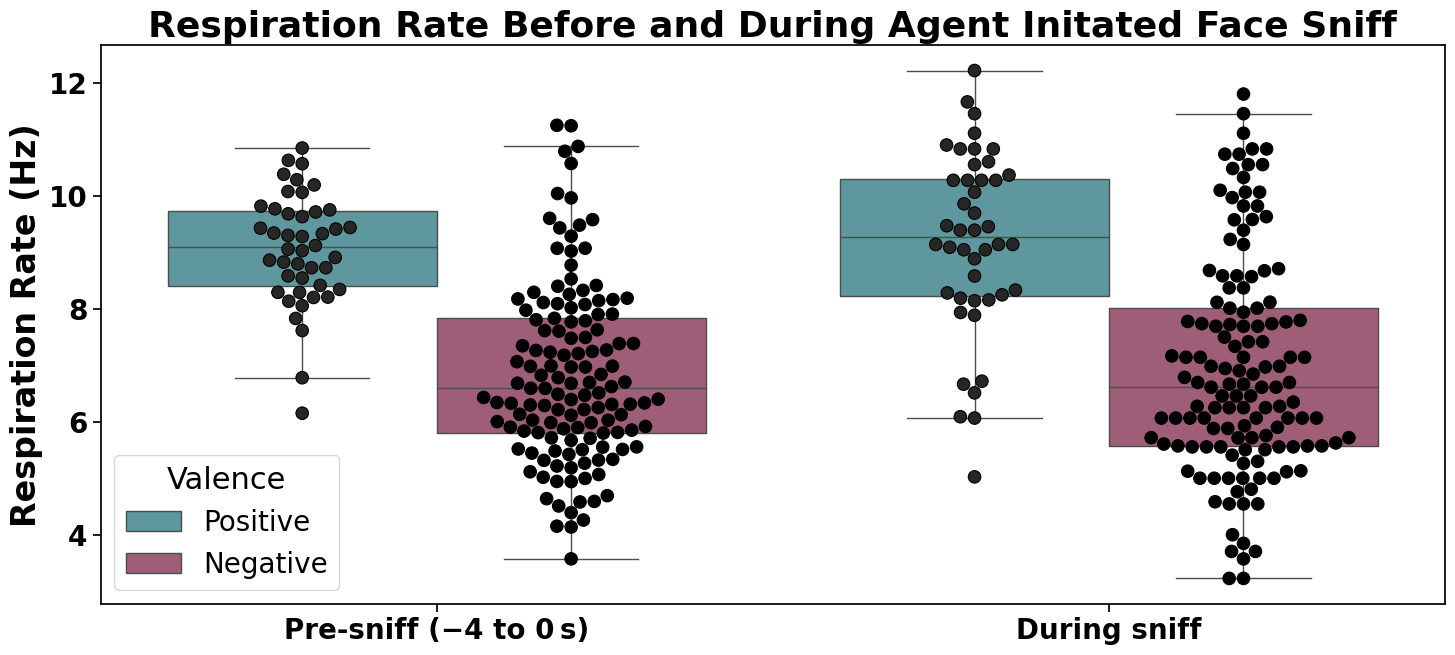

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette for positive and negative valence
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Add 'Valence' column based on 'Trial' string
results_df['Valence'] = results_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
results_df = results_df[results_df['Valence'] != 'Unknown']

# Melt dataframe for plotting
plot_df = results_df.melt(
    id_vars=["Trial", "Valence"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename conditions for clarity
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−4 to 0 s)",
    "Post-sniff Rate": "During sniff"
})

# Set up plot
plt.figure(figsize=(15, 7))
sns.set_context("notebook", font_scale=1.8)

# Boxplot
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot overlay
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=9,
    marker='o',
    linewidth=0.8,
    legend=False
)

# Labels and formatting
plt.title("Respiration Rate Before and During Agent Initated Face Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=24, weight='bold')
plt.xlabel('', fontsize=22)
plt.xticks(fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')
plt.legend(title='Valence', fontsize=20, title_fontsize=22, loc='lower left', bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.show()


In [ ]:
results_df

,Trial,Sniff Start,Percent Change,Baseline Rate,Post-sniff Rate,Valence
0,RI1_3_6,12.069,40.676642,8.293251,11.666667,Positive
1,RI1_3_6,86.207,10.004107,9.343085,10.277778,Positive
2,RI1_3_6,88.034,0.916251,9.058416,9.141414,Positive
3,RI1_3_6,107.724,-11.677579,10.064136,8.888889,Positive
4,RI1_3_6,183.724,10.348498,8.585148,9.473582,Positive
5,RI1_3_6,200.517,-30.232249,8.728594,6.089744,Positive
6,RI1_3_6,217.172,21.402426,8.292536,10.067340,Positive
7,RI1_3_6,229.897,5.411681,8.911668,9.393939,Positive
8,RI1_3_6,243.793,-39.789755,8.344942,5.024510,Positive
9,RI1_3_6,337.172,-0.615095,8.209001,8.158508,Positive


C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\4085731915.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, palette=["gray", "orange"])


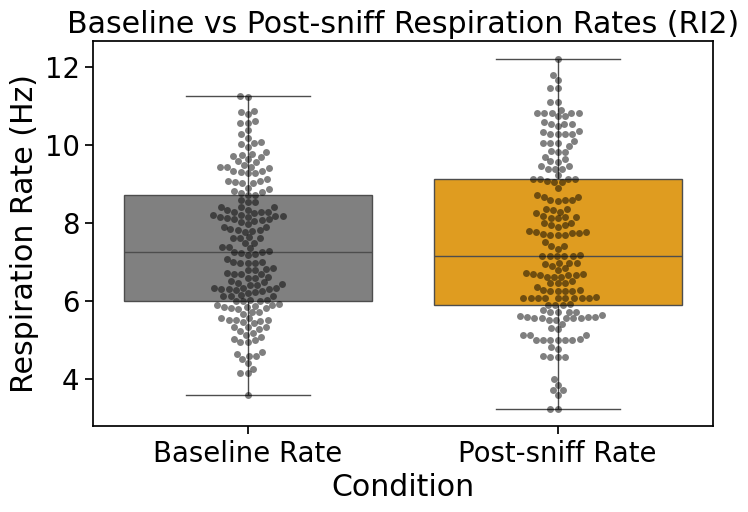

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape data for plotting baseline vs post side-by-side
plot_df = results_df.melt(
    id_vars=["Trial", "Sniff Start"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, palette=["gray", "orange"])
sns.swarmplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, color="black", alpha=0.5)

plt.title("Baseline vs Post-sniff Respiration Rates (RI2)")
plt.ylabel("Respiration Rate (Hz)")
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\1314123701.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, palette=["gray", "orange"])


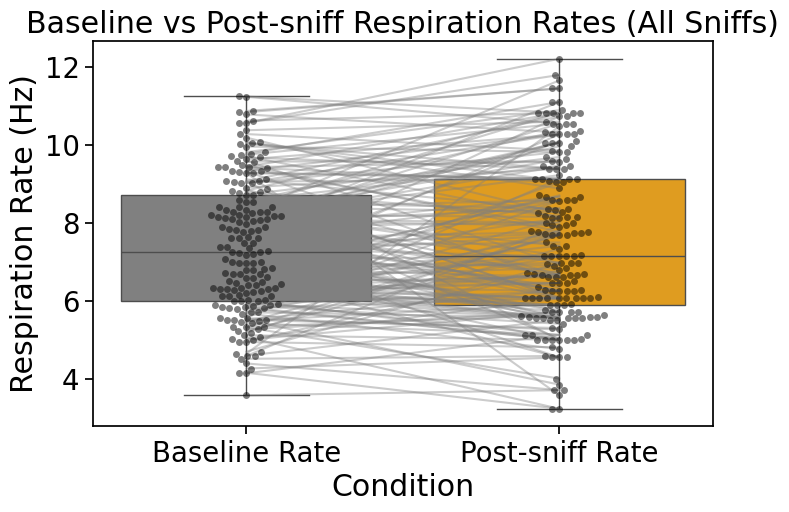

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = results_df.melt(
    id_vars=["Trial", "Sniff Start"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

plt.figure(figsize=(8, 5))

# Boxplot
sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, palette=["gray", "orange"])

# Swarmplot with points
sns.swarmplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, color="black", alpha=0.5)

# Connect points from same sniff event with lines
for (trial, sniff_start), group in plot_df.groupby(["Trial", "Sniff Start"]):
    if len(group) == 2:
        x_vals = [0, 1]  # Baseline is at x=0, Post-sniff at x=1
        y_vals = group.sort_values("Condition")["Respiration Rate (Hz)"].values
        plt.plot(x_vals, y_vals, color="gray", alpha=0.4)

plt.title("Baseline vs Post-sniff Respiration Rates (All Sniffs)")
plt.ylabel("Respiration Rate (Hz)")
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\3168548869.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI1, palette=["gray", "orange"], ax=axes[0])
C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\3168548869.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI2, palette=["gray", "orange"], ax=axes[1])


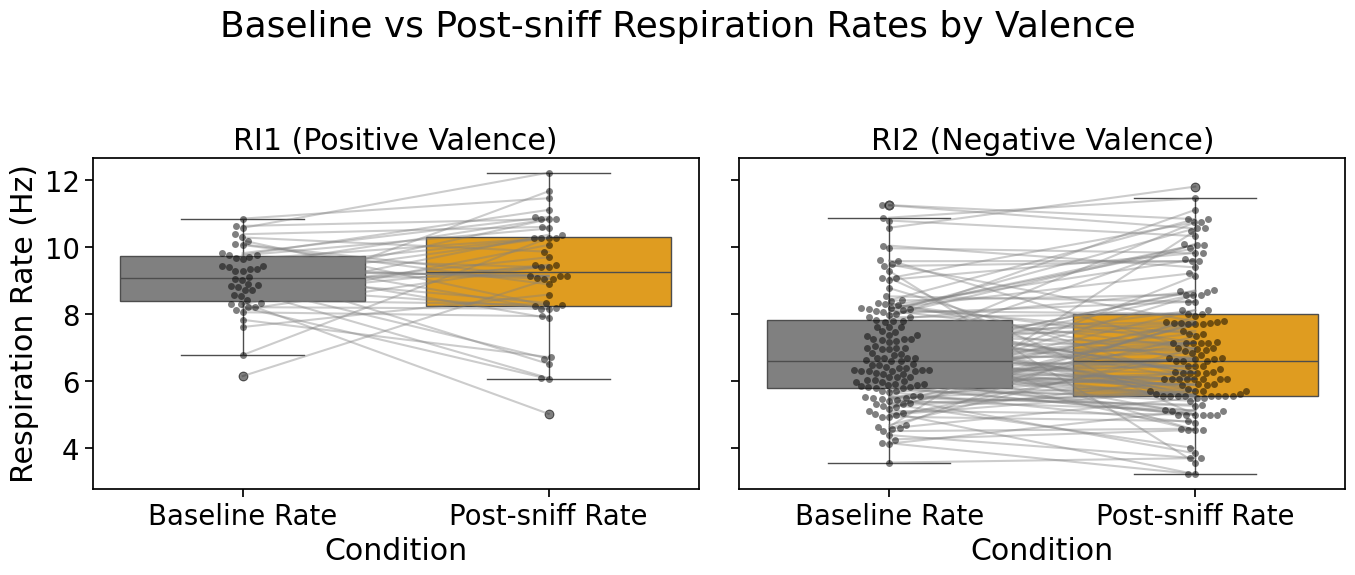

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for RI1 and RI2
plot_df_RI1 = plot_df[plot_df['Trial'].str.startswith('RI1')]
plot_df_RI2 = plot_df[plot_df['Trial'].str.startswith('RI2')]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for RI1
sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI1, palette=["gray", "orange"], ax=axes[0])
sns.swarmplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI1, color="black", alpha=0.5, ax=axes[0])

for (trial, sniff_start), group in plot_df_RI1.groupby(["Trial", "Sniff Start"]):
    if len(group) == 2:
        x_vals = [0, 1]
        y_vals = group.sort_values("Condition")["Respiration Rate (Hz)"].values
        axes[0].plot(x_vals, y_vals, color="gray", alpha=0.4)

axes[0].set_title("RI1 (Positive Valence)")
axes[0].set_ylabel("Respiration Rate (Hz)")

# Plot for RI2
sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI2, palette=["gray", "orange"], ax=axes[1])
sns.swarmplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI2, color="black", alpha=0.5, ax=axes[1])

for (trial, sniff_start), group in plot_df_RI2.groupby(["Trial", "Sniff Start"]):
    if len(group) == 2:
        x_vals = [0, 1]
        y_vals = group.sort_values("Condition")["Respiration Rate (Hz)"].values
        axes[1].plot(x_vals, y_vals, color="gray", alpha=0.4)

axes[1].set_title("RI2 (Negative Valence)")
axes[1].set_ylabel("")  # No ylabel on right subplot to reduce clutter

plt.suptitle("Baseline vs Post-sniff Respiration Rates by Valence")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sniff_rates = []

for i, sniff_row in combined_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]
    sniff_end = sniff_row["Stop (s)"]

    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=sampling_rate)

    sniff_rates.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Sniff End": sniff_end,
        "Sniff Duration": sniff_end - sniff_start,
        "Sniff Resp Rate (Hz)": rate
    })

sniff_rates_df = pd.DataFrame(sniff_rates)
print(sniff_rates_df.head())


     Trial  Sniff Start  Sniff End  Sniff Duration  Sniff Resp Rate (Hz)
0  RI1_3_6       12.069     12.862           0.793              7.566204
1  RI1_3_6       86.207     87.414           1.207              7.456504
2  RI1_3_6       88.034     88.828           0.794             10.075567
3  RI1_3_6      107.724    108.483           0.759              7.905138
4  RI1_3_6      183.724    184.621           0.897              8.918618


In [ ]:
sniff_rates_df

,Trial,Sniff Start,Sniff End,Sniff Duration,Sniff Resp Rate (Hz)
0,RI1_3_6,12.069,12.862,0.793,7.566204
1,RI1_3_6,86.207,87.414,1.207,7.456504
2,RI1_3_6,88.034,88.828,0.794,10.075567
3,RI1_3_6,107.724,108.483,0.759,7.905138
4,RI1_3_6,183.724,184.621,0.897,8.918618
5,RI1_3_6,200.517,200.966,0.449,4.454343
6,RI1_3_6,217.172,217.655,0.483,8.281573
7,RI1_3_6,229.897,230.655,0.758,7.915567
8,RI1_3_6,243.793,244.310,0.517,5.802708
9,RI1_3_6,337.172,339.552,2.380,6.722689


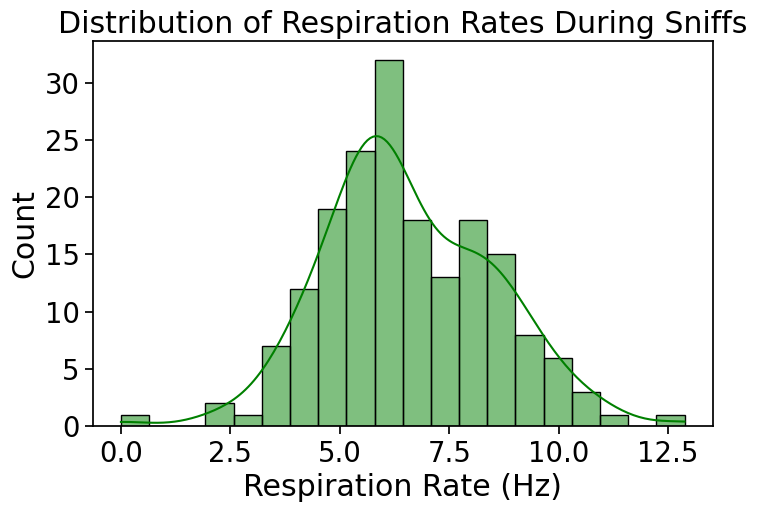

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(sniff_rates_df["Sniff Resp Rate (Hz)"], bins=20, kde=True, color="green")
plt.title("Distribution of Respiration Rates During Sniffs")
plt.xlabel("Respiration Rate (Hz)")
plt.ylabel("Count")
plt.show()


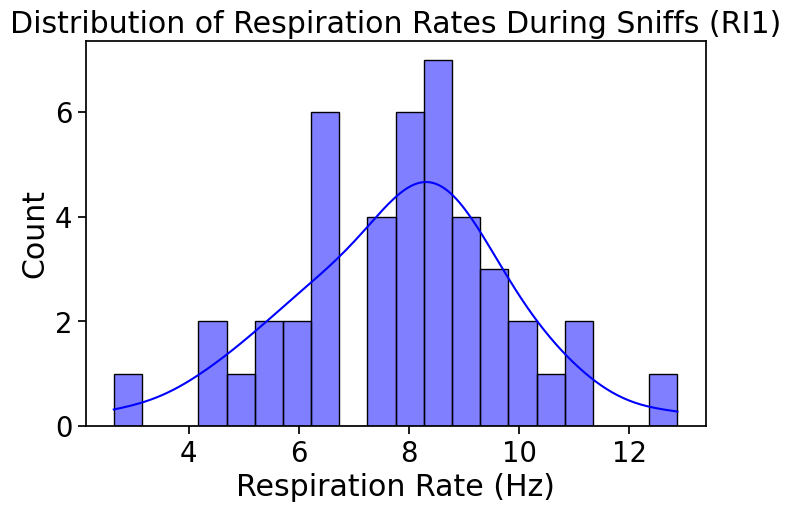

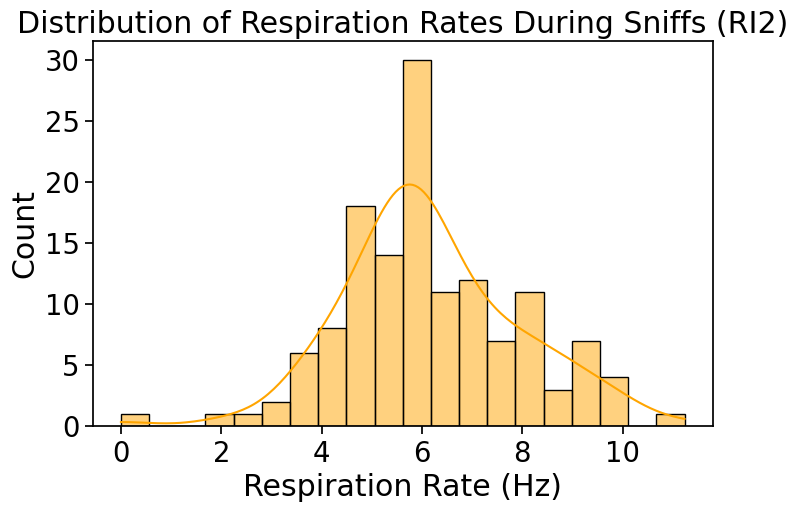

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter RI1 sniff rates
ri1_rates = sniff_rates_df[sniff_rates_df['Trial'].str.startswith('RI1')]

plt.figure(figsize=(8, 5))
sns.histplot(ri1_rates["Sniff Resp Rate (Hz)"], bins=20, kde=True, color="blue")
plt.title("Distribution of Respiration Rates During Sniffs (RI1)")
plt.xlabel("Respiration Rate (Hz)")
plt.ylabel("Count")
plt.show()

# Filter RI2 sniff rates
ri2_rates = sniff_rates_df[sniff_rates_df['Trial'].str.startswith('RI2')]

plt.figure(figsize=(8, 5))
sns.histplot(ri2_rates["Sniff Resp Rate (Hz)"], bins=20, kde=True, color="orange")
plt.title("Distribution of Respiration Rates During Sniffs (RI2)")
plt.xlabel("Respiration Rate (Hz)")
plt.ylabel("Count")
plt.show()


In [ ]:
import pandas as pd

# Combine RI1 and RI2 BORIS data into one dataframe with a 'Trial' column
all_boris = []

for label, boris_df in {**ri1_boris_data, **ri2_boris_data}.items():
    df = boris_df.copy()
    df['Trial'] = label
    all_boris.append(df)

combined_boris_df = pd.concat(all_boris, ignore_index=True)

# Make sure Start and Stop are floats
combined_boris_df['Start (s)'] = combined_boris_df['Start (s)'].astype(float)
combined_boris_df['Stop (s)'] = combined_boris_df['Stop (s)'].astype(float)

# Calculate duration
combined_boris_df['Duration'] = combined_boris_df['Stop (s)'] - combined_boris_df['Start (s)']

# Filter by duration threshold (≥ 0.3 seconds)
filtered_behaviors = combined_boris_df[combined_boris_df['Duration'] >= 0.3]

# Prepare to store results
results = []

for idx, row in filtered_behaviors.iterrows():
    trial = row['Trial']
    subject = row['Subject'] 
    behavior = row['Behavior']
    start = row['Start (s)']
    stop = row['Stop (s)']

    # Get respiration data for the trial
    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry['signal']
    time = resp_entry['time']
    sampling_rate = resp_entry['sampling_rate']

    # Calculate respiratory rate during the behavior bout
    rate = get_sniff_respiratory_rate(signal, time, start, stop, sampling_rate=sampling_rate)

    results.append({
        'Trial': trial,
        'Subject': subject,
        'Behavior': behavior,
        'Start (s)': start,
        'Stop (s)': stop,
        'Duration (s)': stop - start,
        'Respiration Rate (Hz)': rate
    })

results_df = pd.DataFrame(results)

print(results_df.head())


     Trial       Subject             Behavior  Start (s)  Stop (s)  \
0  RI1_3_6  social_agent  anogenital sniffing      8.862     9.448   
1  RI1_3_6       subject      facial sniffing     11.966    13.000   
2  RI1_3_6  social_agent      facial sniffing     12.069    12.862   
3  RI1_3_6       subject  anogenital sniffing     14.483    16.690   
4  RI1_3_6       subject  anogenital sniffing     19.069    19.483   

   Duration (s)  Respiration Rate (Hz)  
0         0.586               5.119454  
1         1.034               6.769826  
2         0.793               7.566204  
3         2.207               8.608971  
4         0.414               4.830918  


In [ ]:
results_df

,Trial,Subject,Behavior,Start (s),Stop (s),Duration (s),Respiration Rate (Hz)
0,RI1_3_6,social_agent,anogenital sniffing,8.862,9.448,0.586,5.119454
1,RI1_3_6,subject,facial sniffing,11.966,13.000,1.034,6.769826
2,RI1_3_6,social_agent,facial sniffing,12.069,12.862,0.793,7.566204
3,RI1_3_6,subject,anogenital sniffing,14.483,16.690,2.207,8.608971
4,RI1_3_6,subject,anogenital sniffing,19.069,19.483,0.414,4.830918
5,RI1_3_6,subject,anogenital sniffing,21.379,21.724,0.345,11.594203
6,RI1_3_6,subject,anogenital sniffing,25.034,27.552,2.518,8.339952
7,RI1_3_6,subject,body sniffing,27.793,28.448,0.655,9.160305
8,RI1_3_6,subject,anogenital sniffing,28.862,29.861,0.999,8.008008
9,RI1_3_6,subject,body sniffing,29.862,30.586,0.724,9.668508


C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2559526131.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Behavior'] = pd.Categorical(df['Behavior'], categories=behavior_order, ordered=True)
C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2559526131.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Behavior', y='Respiration Rate (Hz)', data=data, order=behavior_order, palette='Set2', inner='box')
C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2559526131.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign th

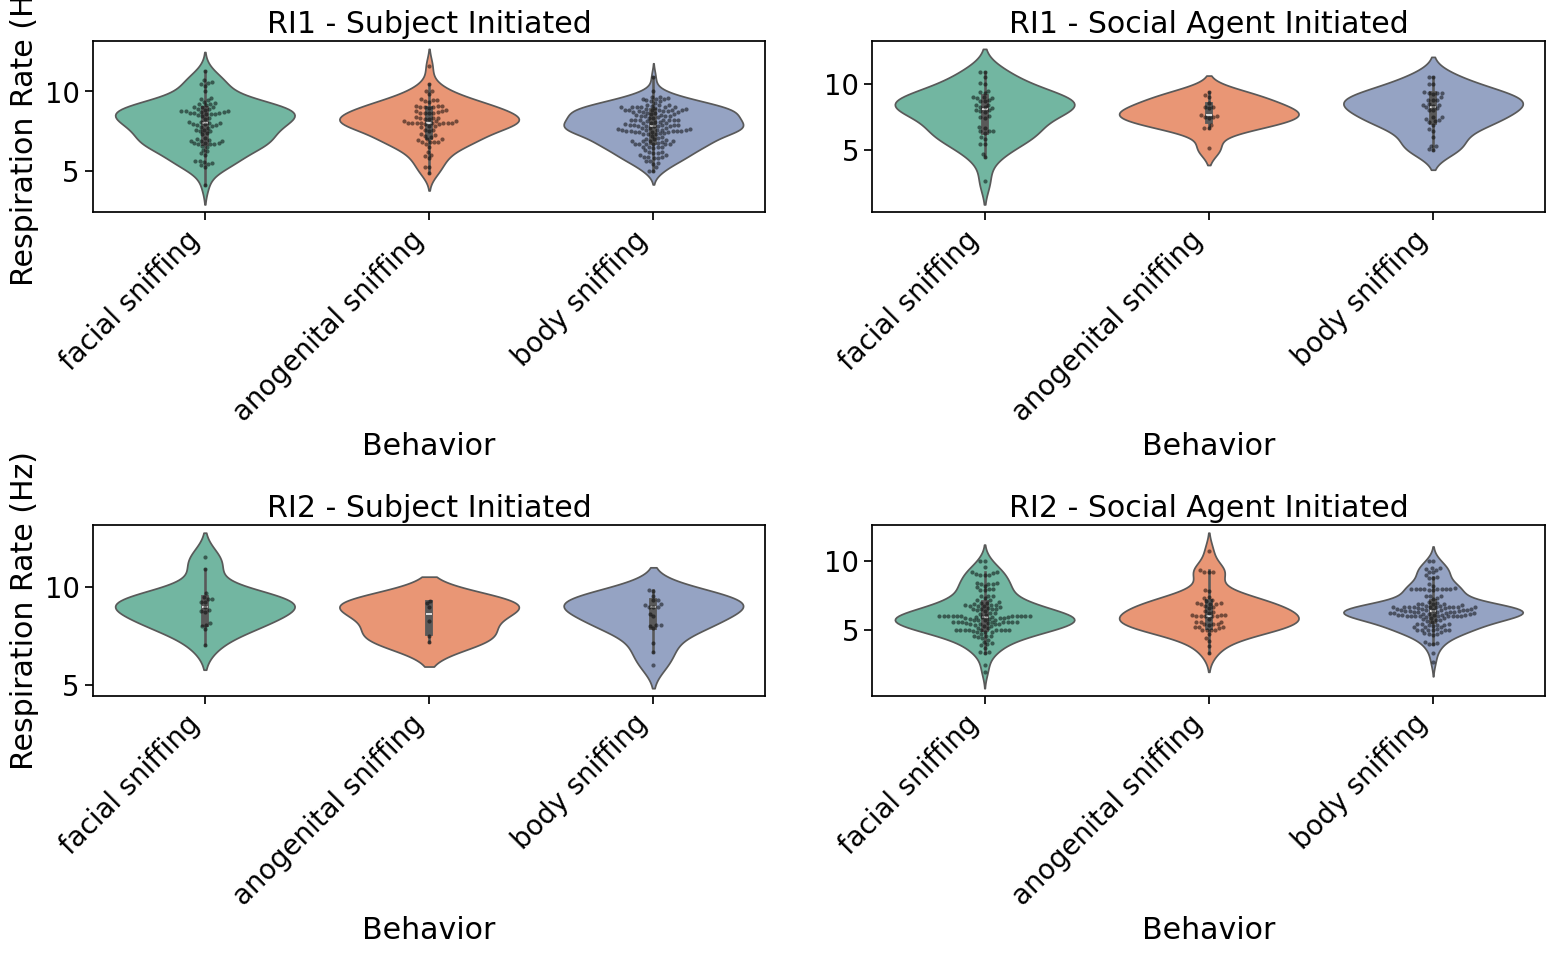

In [ ]:
# Normalize casing to avoid mismatch
results_df['Subject'] = results_df['Subject'].str.lower()

# Add Valence column
results_df['Valence'] = results_df['Trial'].apply(lambda x: 'RI1' if x.startswith('RI1') else ('RI2' if x.startswith('RI2') else 'Other'))

# Split data by valence and subject
ri1_subject_df = results_df[(results_df['Valence'] == 'RI1') & (results_df['Subject'] == 'subject')]
ri1_agent_df = results_df[(results_df['Valence'] == 'RI1') & (results_df['Subject'] == 'social_agent')]
ri2_subject_df = results_df[(results_df['Valence'] == 'RI2') & (results_df['Subject'] == 'subject')]
ri2_agent_df = results_df[(results_df['Valence'] == 'RI2') & (results_df['Subject'] == 'social_agent')]

# Use RI1 subject-initiated behavior order as the base
behavior_order = ri1_subject_df['Behavior'].unique().tolist()

# Set behavior category order
for df in [ri1_subject_df, ri1_agent_df, ri2_subject_df, ri2_agent_df]:
    df['Behavior'] = pd.Categorical(df['Behavior'], categories=behavior_order, ordered=True)

# Plotting function for all four groups
def plot_by_initiator_and_valence():
    plt.figure(figsize=(16, 10))

    def plot_subplot(data, title, subplot_index):
        plt.subplot(2, 2, subplot_index)
        sns.violinplot(x='Behavior', y='Respiration Rate (Hz)', data=data, order=behavior_order, palette='Set2', inner='box')
        sns.swarmplot(x='Behavior', y='Respiration Rate (Hz)', data=data, order=behavior_order, color='k', alpha=0.5, size=3)
        plt.title(title)
        plt.xticks(rotation=45, ha='right')
        if subplot_index in [1, 3]:
            plt.ylabel('Respiration Rate (Hz)')
        else:
            plt.ylabel('')
        plt.xlabel('Behavior')

    plot_subplot(ri1_subject_df, 'RI1 - Subject Initiated', 1)
    plot_subplot(ri1_agent_df, 'RI1 - Social Agent Initiated', 2)
    plot_subplot(ri2_subject_df, 'RI2 - Subject Initiated', 3)
    plot_subplot(ri2_agent_df, 'RI2 - Social Agent Initiated', 4)

    plt.tight_layout()
    plt.show()

plot_by_initiator_and_valence()


In [ ]:
# Replace RI1 and RI2 with descriptive labels
results_df['Valence'] = results_df['Trial'].apply(
    lambda x: 'Positive Social Interaction' if x.startswith('RI1') else (
        'Negative Social Interaction' if x.startswith('RI2') else 'Other'
    )
)


In [ ]:
pos_subject_df = results_df[(results_df['Valence'] == 'Positive Social Interaction') & (results_df['Subject'] == 'subject')]
pos_agent_df = results_df[(results_df['Valence'] == 'Positive Social Interaction') & (results_df['Subject'] == 'social_agent')]

neg_subject_df = results_df[(results_df['Valence'] == 'Negative Social Interaction') & (results_df['Subject'] == 'subject')]
neg_agent_df = results_df[(results_df['Valence'] == 'Negative Social Interaction') & (results_df['Subject'] == 'social_agent')]


In [ ]:
behavior_order = pos_subject_df['Behavior'].unique().tolist()

for df in [pos_subject_df, pos_agent_df, neg_subject_df, neg_agent_df]:
    df['Behavior'] = pd.Categorical(df['Behavior'], categories=behavior_order, ordered=True)


C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\1139435840.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Behavior'] = pd.Categorical(df['Behavior'], categories=behavior_order, ordered=True)


In [ ]:
# You can customize palettes — here are example sets:
subject_palette = sns.color_palette("Blues", n_colors=len(behavior_order))
agent_palette = sns.color_palette("Oranges", n_colors=len(behavior_order))


In [ ]:
pos_subject_df = results_df[(results_df['Valence'] == 'Positive Social Interaction') & (results_df['Subject'] == 'subject')]
pos_agent_df = results_df[(results_df['Valence'] == 'Positive Social Interaction') & (results_df['Subject'] == 'social_agent')]

neg_subject_df = results_df[(results_df['Valence'] == 'Negative Social Interaction') & (results_df['Subject'] == 'subject')]
neg_agent_df = results_df[(results_df['Valence'] == 'Negative Social Interaction') & (results_df['Subject'] == 'social_agent')]


In [ ]:
def plot_behavior_by_initiator_valence(behavior_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Prepare dataframes with initiator label
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    # Combine all
    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior'])

    # Clean and map behavior labels
    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map)

    # Filter for chosen behavior
    subset = full_df[full_df['Behavior'] == behavior_name]

    # Palette using your colors
    palette = {
        'Positive': '#53A1A9',
        'Negative': '#A95376'
    }

    # Plot Subject Initiated
    plt.figure(figsize=(9, 6))
    subj_data = subset[subset['Initiator'] == 'Subject']
    sns.violinplot(
        x='Valence', y='Respiration Rate (Hz)', data=subj_data,
        palette=palette, inner='box'
    )
    sns.swarmplot(
        x='Valence', y='Respiration Rate (Hz)', data=subj_data,
        color='k', alpha=0.5, size=8
    )
    plt.title(f'{behavior_name} - Subject Initiated', fontsize=24, fontweight='bold')
    plt.ylim(0, 15)
    plt.ylabel('Respiration Rate (Hz)', fontsize=18)
    plt.xlabel('')
    plt.xticks(fontsize=20, fontweight='bold')
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()

    # Plot Agent Initiated
    plt.figure(figsize=(9, 6))
    agent_data = subset[subset['Initiator'] == 'Agent']
    sns.violinplot(
        x='Valence', y='Respiration Rate (Hz)', data=agent_data,
        palette=palette, inner='box'
    )
    sns.swarmplot(
        x='Valence', y='Respiration Rate (Hz)', data=agent_data,
        color='k', alpha=0.5, size=8
    )
    plt.title(f'{behavior_name} - Agent Initiated', fontsize=24, fontweight='bold')
    plt.ylim(0, 15)
    plt.ylabel('Respiration Rate (Hz)', fontsize=18)
    plt.xlabel('')
    plt.xticks(fontsize=20, fontweight='bold')
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2703756894.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


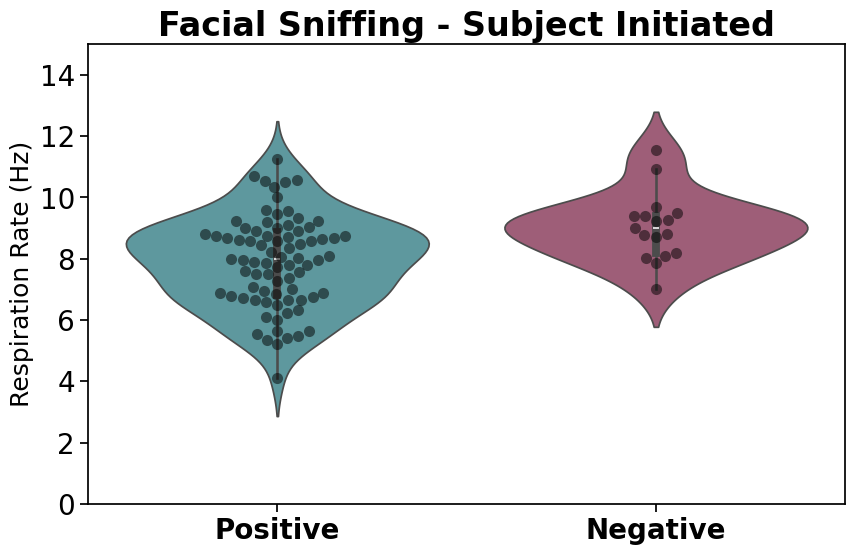

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2703756894.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


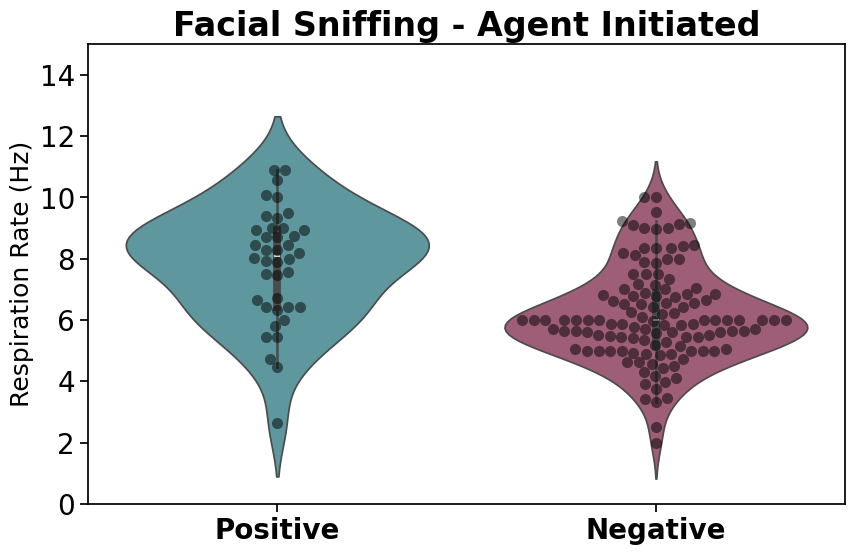

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2703756894.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


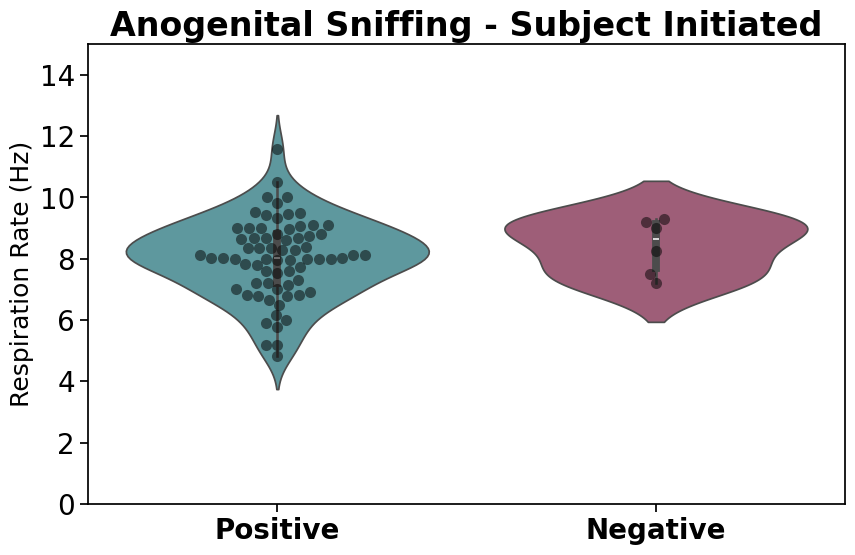

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2703756894.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


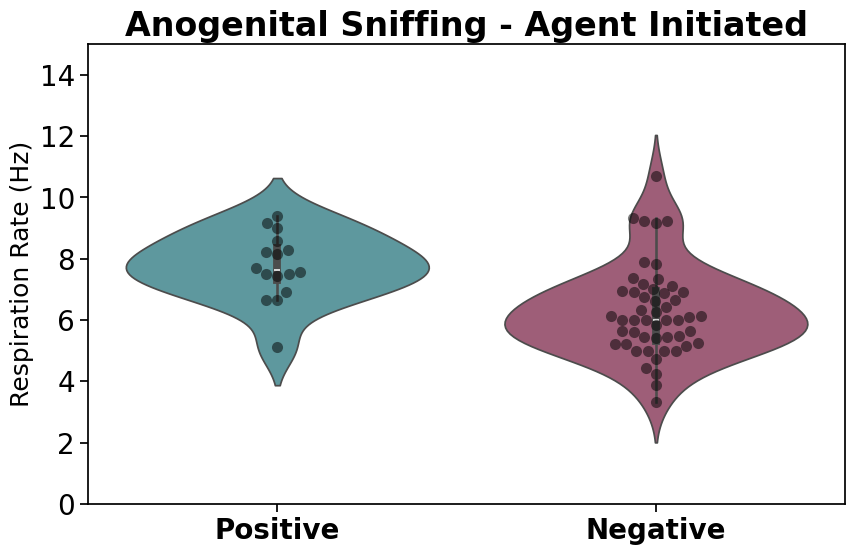

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2703756894.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


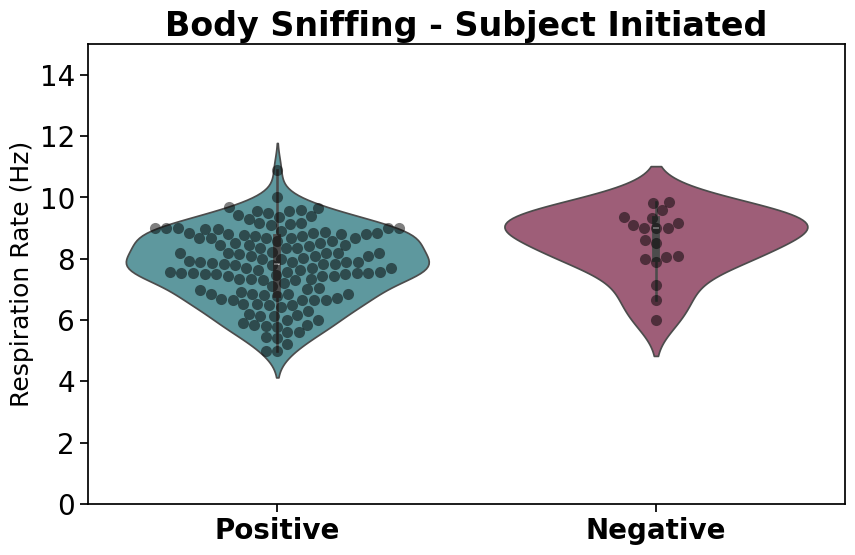

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\2703756894.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


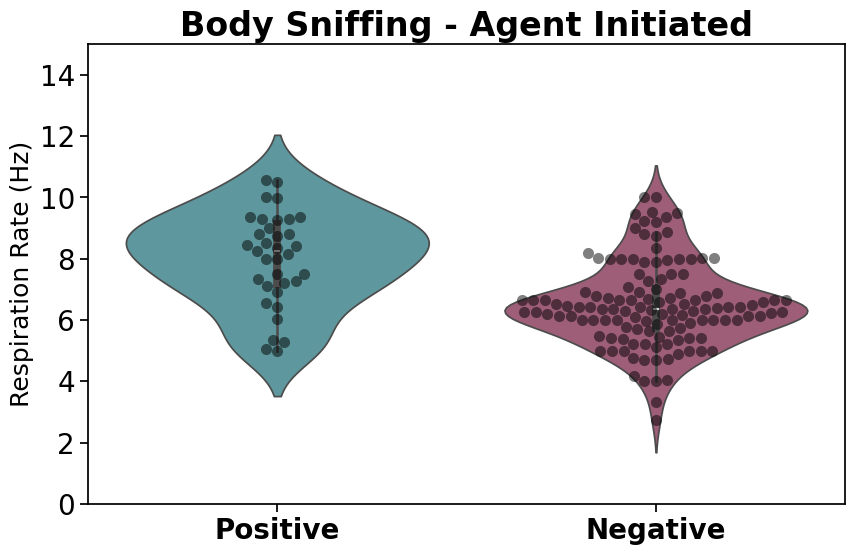

In [ ]:
plot_behavior_by_initiator_valence('Facial Sniffing')
plot_behavior_by_initiator_valence('Anogenital Sniffing')
plot_behavior_by_initiator_valence('Body Sniffing')


In [ ]:
def plot_behavior_by_initiator_valence(behavior_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Label valence and initiator
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    # Combine all
    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior', 'Trial', 'Respiration Rate (Hz)'])

    # Extract SubjectID from Trial
    def extract_subject(trial_str):
        parts = trial_str.split('_')
        return parts[-2] + '_' + parts[-1] if len(parts) >= 3 else None

    full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

    # Clean behavior labels
    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map)

    # Filter for behavior
    subset = full_df[full_df['Behavior'] == behavior_name]

    # Color palette
    palette = {'Positive': '#53A1A9', 'Negative': '#A95376'}

    # Helper to plot a panel
    def plot_panel(data, initiator, title_suffix):
        plt.figure(figsize=(9, 6))
        sns.violinplot(
            x='Valence', y='Respiration Rate (Hz)', data=data,
            palette=palette, inner='box'
        )
        sns.swarmplot(
            x='Valence', y='Respiration Rate (Hz)', data=data,
            color='k', alpha=0.5, size=6
        )

        # Aggregate first
        agg_data = data.groupby(['SubjectID', 'Valence'])['Respiration Rate (Hz)'].mean().reset_index()
        paired = agg_data.pivot(index='SubjectID', columns='Valence', values='Respiration Rate (Hz)').dropna()

        # Plot connecting lines
        for _, row in paired.iterrows():
            plt.plot([0, 1], [row['Positive'], row['Negative']], color='gray', alpha=0.4, linewidth=1)


        plt.title(f'{behavior_name} - {title_suffix}', fontsize=24, fontweight='bold')
        plt.ylim(0, 15)
        plt.ylabel('Respiration Rate (Hz)', fontsize=18)
        plt.xlabel('')
        plt.xticks([0, 1], ['Positive', 'Negative'], fontsize=20, fontweight='bold')
        plt.yticks(fontsize=20)
        plt.tight_layout()
        plt.show()

    # Subject-initiated
    plot_panel(subset[subset['Initiator'] == 'Subject'], 'Subject', 'Subject Initiated')

    # Agent-initiated
    plot_panel(subset[subset['Initiator'] == 'Agent'], 'Agent', 'Agent Initiated')


C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


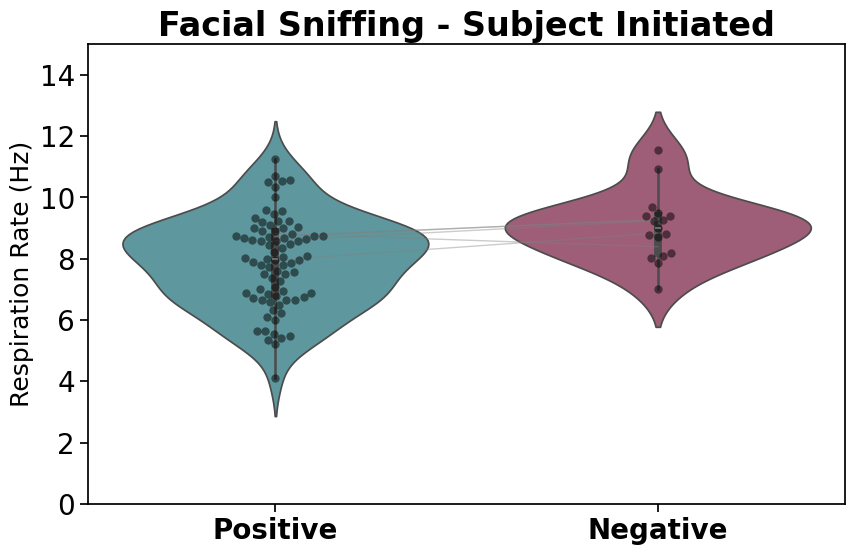

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


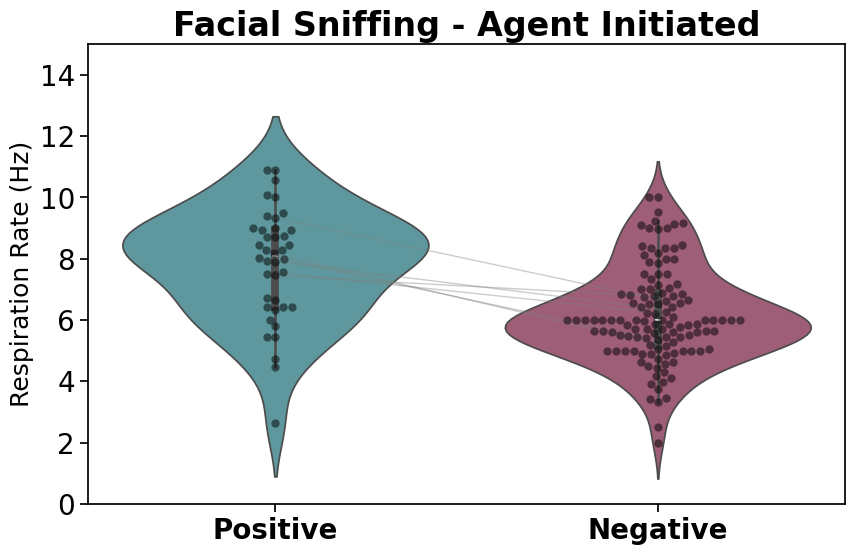

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


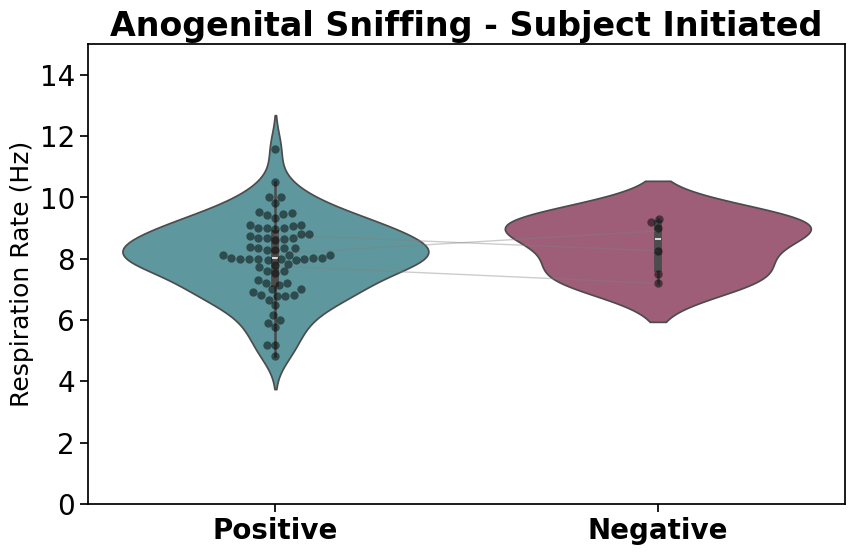

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


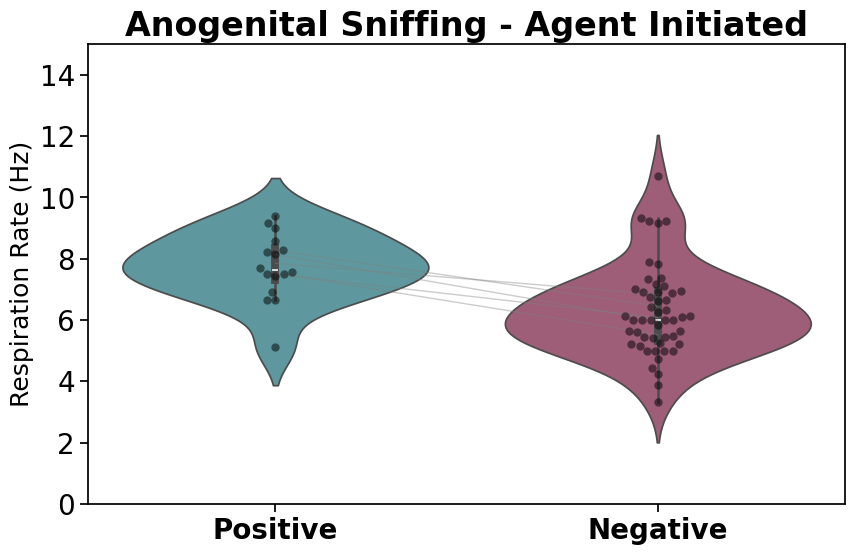

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


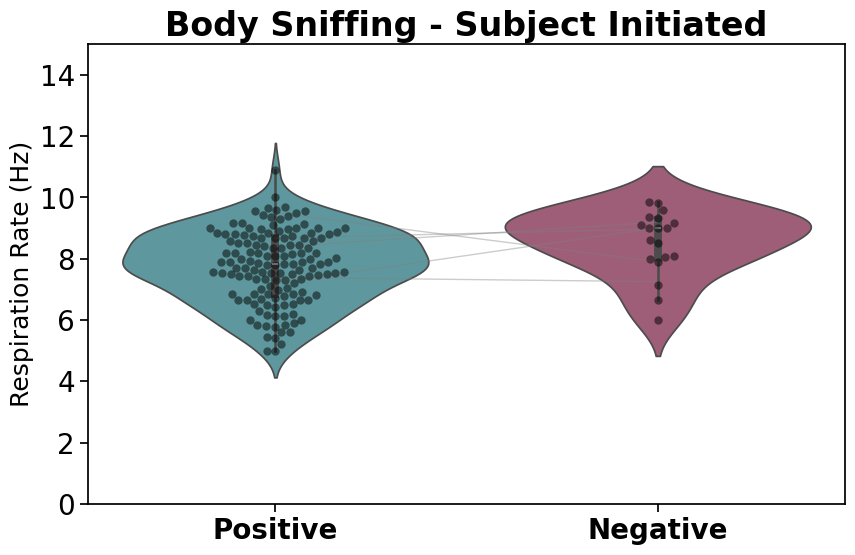

C:\Users\sjs93\AppData\Local\Temp\ipykernel_72964\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


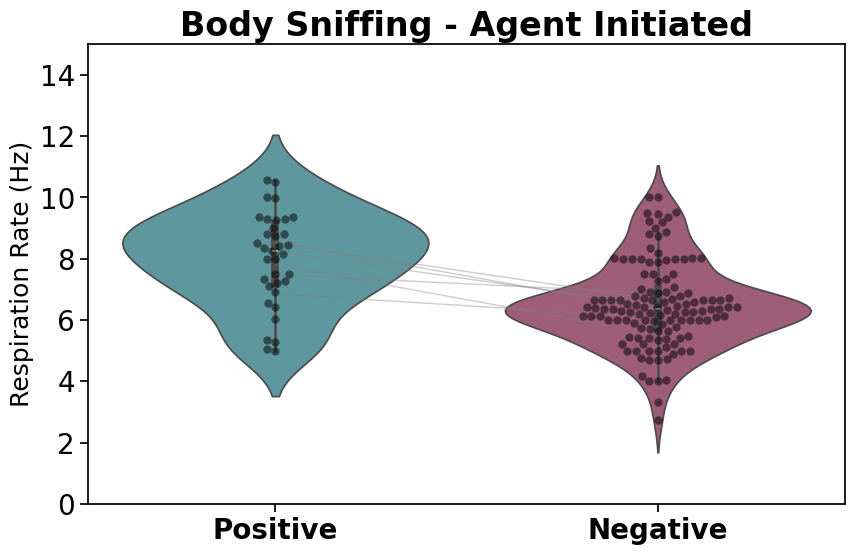

In [ ]:
plot_behavior_by_initiator_valence('Facial Sniffing')
plot_behavior_by_initiator_valence('Anogenital Sniffing')
plot_behavior_by_initiator_valence('Body Sniffing')

In [ ]:
print(type(ri1_boris_data))
print(ri1_boris_data.keys() if isinstance(ri1_boris_data, dict) else ri1_boris_data[0])


<class 'dict'>
dict_keys(['RI1_3_6', 'RI1_4_7', 'RI1_2_3', 'RI1_4_8', 'RI1_1_1', 'RI1_1_2', 'RI1_2_4'])


In [ ]:
result_list = []

for sniff in sniff_events:  # Loop over each sniff time
    percent_change, baseline, post = calculate_percent_change_resp_rate(
        signal, time, sniff['Start (s)'], plot=False
    )
    if percent_change is not None:
        result_list.append({
            'Valence': sniff['Valence'],  # 'Positive' or 'Negative'
            'PercentChange': percent_change
        })

df = pd.DataFrame(result_list)


NameError: name 'sniff_events' is not defined

In [ ]:
result_list = []

for sniff in sniff_events:  # Loop over each sniff time
    percent_change, baseline, post = calculate_percent_change_resp_rate(
        signal, time, sniff['Start (s)'], plot=False
    )
    if percent_change is not None:
        result_list.append({
            'Valence': sniff['Valence'],  # 'Positive' or 'Negative'
            'PercentChange': percent_change
        })

df = pd.DataFrame(result_list)


NameError: name 'sniff_events' is not defined

In [ ]:
def plot_paired_behavior(behavior_name, initiator_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Prepare and combine data with valence and initiator labels (same as before)
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior', 'Trial', 'Respiration Rate (Hz)'])

    # Extract SubjectID from Trial (reuse your function)
    def extract_subject(trial_str):
        parts = trial_str.split('_')
        if len(parts) >= 3:
            return parts[-2] + '_' + parts[-1]
        else:
            return None
    full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

    # Clean behavior labels
    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map).fillna(full_df['Behavior'])

    # Filter for behavior and initiator
    df = full_df[(full_df['Behavior'] == behavior_name) & (full_df['Initiator'] == initiator_name)]

    # Aggregate respiration rate per subject and valence
    agg_df = df.groupby(['SubjectID', 'Valence'])['Respiration Rate (Hz)'].mean().reset_index()

    # Pivot so Positive and Negative are columns for each SubjectID
    paired = agg_df.pivot(index='SubjectID', columns='Valence', values='Respiration Rate (Hz)').dropna()

    # Plot paired data
    plt.figure(figsize=(6,6))
    plt.title(f'{behavior_name} - {initiator_name} Initiated (Paired)', fontsize=16, fontweight='bold')
    plt.ylabel('Respiration Rate (Hz)', fontsize=14)
    plt.xticks([0,1], ['Positive', 'Negative'], fontsize=14, fontweight='bold')
    plt.ylim(0, 15)

    # Plot points for each subject and connect pairs with a line
    for subject in paired.index:
        plt.plot([0,1], paired.loc[subject, ['Positive', 'Negative']], marker='o', color='gray', alpha=0.6)

    # Also plot summary points (means)
    means = paired.mean()
    plt.scatter([0,1], means, color='red', s=100, label='Mean', zorder=5)
    plt.legend()

    plt.tight_layout()
    plt.show()


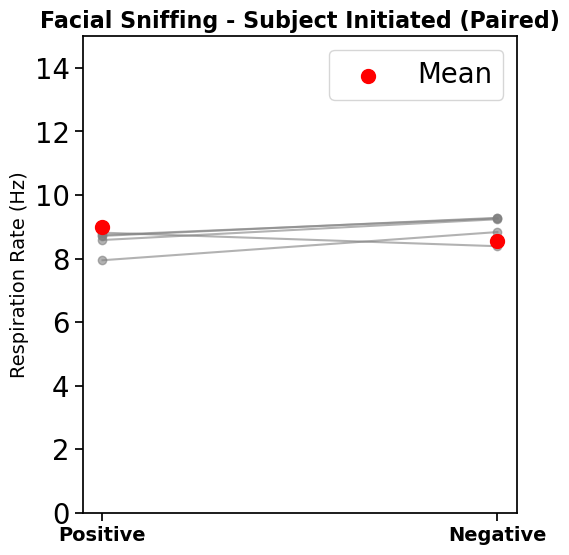

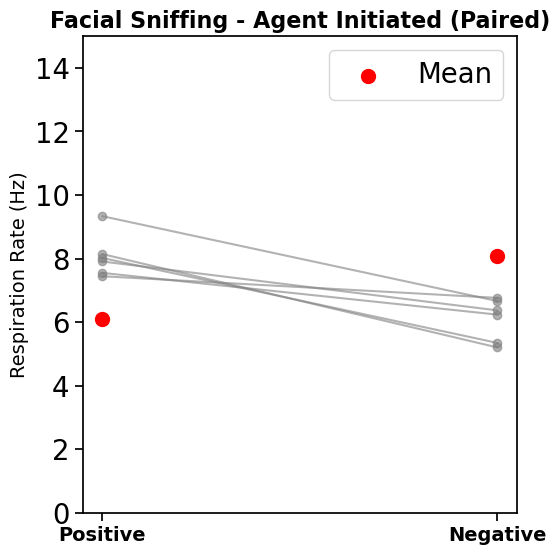

In [ ]:
plot_paired_behavior('Facial Sniffing', 'Subject')
plot_paired_behavior('Facial Sniffing', 'Agent')


In [ ]:
# Step 1: Create full_df as before
pos_subject_df_labeled = pos_subject_df.copy()
pos_subject_df_labeled['Valence'] = 'Positive'
pos_subject_df_labeled['Initiator'] = 'Subject'

neg_subject_df_labeled = neg_subject_df.copy()
neg_subject_df_labeled['Valence'] = 'Negative'
neg_subject_df_labeled['Initiator'] = 'Subject'

pos_agent_df_labeled = pos_agent_df.copy()
pos_agent_df_labeled['Valence'] = 'Positive'
pos_agent_df_labeled['Initiator'] = 'Agent'

neg_agent_df_labeled = neg_agent_df.copy()
neg_agent_df_labeled['Valence'] = 'Negative'
neg_agent_df_labeled['Initiator'] = 'Agent'

full_df = pd.concat([
    pos_subject_df_labeled,
    neg_subject_df_labeled,
    pos_agent_df_labeled,
    neg_agent_df_labeled
]).dropna(subset=['Behavior'])

# --- Insert your SubjectID extraction here ---
def extract_subject(trial_str):
    parts = trial_str.split('_')
    if len(parts) >= 3:
        return parts[-2] + '_' + parts[-1]
    else:
        return None

full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

# Now you have full_df with a proper SubjectID column to use for pairing!


In [ ]:
print("✅ pos_subject_df:")
print(pos_subject_df.columns)
print(pos_subject_df.head())
print()

print("✅ neg_subject_df:")
print(neg_subject_df.columns)
print(neg_subject_df.head())
print()

print("✅ pos_agent_df:")
print(pos_agent_df.columns)
print(pos_agent_df.head())
print()

print("✅ neg_agent_df:")
print(neg_agent_df.columns)
print(neg_agent_df.head())


✅ pos_subject_df:
Index(['Trial', 'Subject', 'Behavior', 'Start (s)', 'Stop (s)', 'Duration (s)',
       'Respiration Rate (Hz)', 'Valence'],
      dtype='object')
     Trial  Subject             Behavior  Start (s)  Stop (s)  Duration (s)  \
1  RI1_3_6  subject      facial sniffing     11.966    13.000         1.034   
3  RI1_3_6  subject  anogenital sniffing     14.483    16.690         2.207   
4  RI1_3_6  subject  anogenital sniffing     19.069    19.483         0.414   
5  RI1_3_6  subject  anogenital sniffing     21.379    21.724         0.345   
6  RI1_3_6  subject  anogenital sniffing     25.034    27.552         2.518   

   Respiration Rate (Hz)                      Valence  
1               6.769826  Positive Social Interaction  
3               8.608971  Positive Social Interaction  
4               4.830918  Positive Social Interaction  
5              11.594203  Positive Social Interaction  
6               8.339952  Positive Social Interaction  

✅ neg_subject_df:
Index(

In [ ]:
print(pos_subject_df['Subject'].unique())
print(neg_subject_df['Subject'].unique())
print(pos_agent_df['Subject'].unique())
print(neg_agent_df['Subject'].unique())


['subject']
['subject']
['social_agent']
['social_agent']


In [ ]:
print("Missing Behaviors:", pd.concat([
    pos_subject_df_labeled, neg_subject_df_labeled,
    pos_agent_df_labeled, neg_agent_df_labeled
])['Behavior'].isna().sum())

print("Missing Trials:", pd.concat([
    pos_subject_df_labeled, neg_subject_df_labeled,
    pos_agent_df_labeled, neg_agent_df_labeled
])['Trial'].isna().sum())

print("Missing Resp Rate:", pd.concat([
    pos_subject_df_labeled, neg_subject_df_labeled,
    pos_agent_df_labeled, neg_agent_df_labeled
])['Respiration Rate (Hz)'].isna().sum())


Missing Behaviors: 0
Missing Trials: 0
Missing Resp Rate: 0


In [ ]:
print(full_df['Behavior'].value_counts(dropna=False))


Behavior
body sniffing          319
facial sniffing        258
anogenital sniffing    143
fighting               114
Posturing               66
chasing                 27
tails rattling           5
Name: count, dtype: int64


In [ ]:
print(full_df[['Behavior', 'Valence']].head(10))


               Behavior   Valence
1       facial sniffing  Positive
3   anogenital sniffing  Positive
4   anogenital sniffing  Positive
5   anogenital sniffing  Positive
6   anogenital sniffing  Positive
7         body sniffing  Positive
8   anogenital sniffing  Positive
9         body sniffing  Positive
10  anogenital sniffing  Positive
11  anogenital sniffing  Positive


In [ ]:
def run_wilcoxon_on_aggregated_with_subjectid(behavior_name, initiator_name):
    # 1. Combine and label dataframes
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior', 'Trial', 'Respiration Rate (Hz)'])

    # 2. Extract SubjectID from Trial
    def extract_subject(trial_str):
        parts = trial_str.split('_')
        if len(parts) >= 3:
            return parts[-2] + '_' + parts[-1]
        else:
            return None

    full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

    # 3. Clean and map behavior names
    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map).fillna(full_df['Behavior'])

    # 4. Filter for behavior and initiator
    df = full_df[(full_df['Behavior'] == behavior_name) & (full_df['Initiator'] == initiator_name)]

    # 5. Aggregate respiration rate per mouse, valence
    agg_df = df.groupby(['SubjectID', 'Valence'])['Respiration Rate (Hz)'].mean().reset_index()

    # 6. Prepare paired dataframes for Positive and Negative respiration rates
    pos_data = agg_df[agg_df['Valence'] == 'Positive'][['SubjectID', 'Respiration Rate (Hz)']].set_index('SubjectID')
    neg_data = agg_df[agg_df['Valence'] == 'Negative'][['SubjectID', 'Respiration Rate (Hz)']].set_index('SubjectID')

    # 7. Join paired data and drop missing pairs
    paired = pos_data.join(neg_data, lsuffix='_pos', rsuffix='_neg').dropna()

    # 8. Run Wilcoxon signed-rank test
    stat, p = wilcoxon(paired['Respiration Rate (Hz)_pos'], paired['Respiration Rate (Hz)_neg'])

    # 9. Print results
    print(f"Wilcoxon signed-rank test for {behavior_name} - {initiator_name} (aggregated by SubjectID):")
    print(f"Statistic = {stat:.3f}, p-value = {p:.4f}")
    print(f"Number of pairs = {len(paired)}")

    return stat, p


In [ ]:
#print(pos_subject_df['Trial'].unique())
print(neg_subject_df['Trial'].unique())


['RI2_3_6' 'RI2_4_7' 'RI2_2_3' 'RI2_4_8' 'RI2_1_1' 'RI2_1_2' 'RI2_2_4'
 'RI2_3_5']


In [ ]:
run_wilcoxon_on_aggregated_with_subjectid('Facial Sniffing', 'Subject')
run_wilcoxon_on_aggregated_with_subjectid('Facial Sniffing', 'Agent')



Wilcoxon signed-rank test for Facial Sniffing - Subject (aggregated by SubjectID):
Statistic = 1.000, p-value = 0.1250
Number of pairs = 5
Wilcoxon signed-rank test for Facial Sniffing - Agent (aggregated by SubjectID):
Statistic = 0.000, p-value = 0.0312
Number of pairs = 6


(0.0, 0.03125)

In [ ]:
# Define the behaviors and initiators you want to test
behaviors = ['Facial Sniffing', 'Body Sniffing', 'Anogenital Sniffing']
initiators = ['Subject', 'Agent']

# Run Wilcoxon for each combination
results = []

for behavior in behaviors:
    for initiator in initiators:
        print(f"Running test for: {behavior} - {initiator}")
        stat, p = run_wilcoxon_on_aggregated_with_subjectid(behavior, initiator)
        results.append({
            'Behavior': behavior,
            'Initiator': initiator,
            'Statistic': stat,
            'p-value': p
        })


Running test for: Facial Sniffing - Subject
Wilcoxon signed-rank test for Facial Sniffing - Subject (aggregated by SubjectID):
Statistic = 1.000, p-value = 0.1250
Number of pairs = 5
Running test for: Facial Sniffing - Agent
Wilcoxon signed-rank test for Facial Sniffing - Agent (aggregated by SubjectID):
Statistic = 0.000, p-value = 0.0312
Number of pairs = 6
Running test for: Body Sniffing - Subject
Wilcoxon signed-rank test for Body Sniffing - Subject (aggregated by SubjectID):
Statistic = 5.000, p-value = 0.6250
Number of pairs = 5
Running test for: Body Sniffing - Agent
Wilcoxon signed-rank test for Body Sniffing - Agent (aggregated by SubjectID):
Statistic = 0.000, p-value = 0.0312
Number of pairs = 6
Running test for: Anogenital Sniffing - Subject
Wilcoxon signed-rank test for Anogenital Sniffing - Subject (aggregated by SubjectID):
Statistic = 3.000, p-value = 1.0000
Number of pairs = 3
Running test for: Anogenital Sniffing - Agent
Wilcoxon signed-rank test for Anogenital Sniffi

In [ ]:
# Add a SubjectID column by extracting the 2nd and 3rd chunk of the trial name
combined_sniffs_df["SubjectID"] = combined_sniffs_df["Trial"].str.extract(r"RI\d_(\d+_\d+)")


In [ ]:
ri1_subjects = set(combined_sniffs_df[combined_sniffs_df["Trial"].str.startswith("RI1")]["SubjectID"].unique())
ri2_subjects = set(combined_sniffs_df[combined_sniffs_df["Trial"].str.startswith("RI2")]["SubjectID"].unique())

print(f"RI1 subjects: {sorted(ri1_subjects)}")
print(f"RI2 subjects: {sorted(ri2_subjects)}")
print(f"Subjects in both: {sorted(ri1_subjects & ri2_subjects)}")


RI1 subjects: ['1_1', '1_2', '2_3', '2_4', '3_6', '4_7', '4_8']
RI2 subjects: ['1_1', '1_2', '2_3', '2_4', '3_5', '3_6', '4_7', '4_8']
Subjects in both: ['1_1', '1_2', '2_3', '2_4', '3_6', '4_7', '4_8']


In [ ]:
def plot_resp_trace_from_boris_row(row, resp_data, pre=2, post=4):
    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = row['Behavior']
    valence = row['Valence']

    # Check if trial exists in signal data
    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    # Time window around behavior
    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for {trial} around {start:.2f}s.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    # Plot
    plt.figure(figsize=(8, 3))
    plt.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    plt.axvspan(0, stop - start, color='#53A1A9' if valence == 'Positive' else '#A95376', alpha=0.3)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f"{behavior.title()} | {valence} | {trial}")
    plt.xlabel("Time (s) from behavior onset")
    plt.ylabel("Respiration")
    plt.tight_layout()
    plt.show()


In [ ]:
pos_agent_df

,Trial,Subject,Behavior,Start (s),Stop (s),Duration (s),Respiration Rate (Hz),Valence
0,RI1_3_6,social_agent,anogenital sniffing,8.862,9.448,0.586,5.119454,Positive Social Interaction
2,RI1_3_6,social_agent,facial sniffing,12.069,12.862,0.793,7.566204,Positive Social Interaction
15,RI1_3_6,social_agent,anogenital sniffing,80.310,85.552,5.242,9.156810,Positive Social Interaction
16,RI1_3_6,social_agent,facial sniffing,86.207,87.414,1.207,7.456504,Positive Social Interaction
17,RI1_3_6,social_agent,facial sniffing,88.034,88.828,0.794,10.075567,Positive Social Interaction
18,RI1_3_6,social_agent,anogenital sniffing,90.690,91.862,1.172,7.679181,Positive Social Interaction
20,RI1_3_6,social_agent,facial sniffing,107.724,108.483,0.759,7.905138,Positive Social Interaction
21,RI1_3_6,social_agent,facial sniffing,183.724,184.621,0.897,8.918618,Positive Social Interaction
22,RI1_3_6,social_agent,facial sniffing,200.517,200.966,0.449,4.454343,Positive Social Interaction
23,RI1_3_6,social_agent,facial sniffing,217.172,217.655,0.483,8.281573,Positive Social Interaction


In [ ]:
def plot_minimal_resp_trace(row, resp_data, scalebar_sec=0.5):
    import matplotlib.pyplot as plt

    # Force pre and post to 1 second each
    pre = 1
    post = 1

    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = str(row.get('Behavior', '')).strip().title()

    # Normalize valence
    valence_raw = str(row.get('Valence', '')).lower()
    if 'positive' in valence_raw:
        valence = 'Positive'
    elif 'negative' in valence_raw:
        valence = 'Negative'
    else:
        valence = 'Unknown'

    color_map = {
        'Positive': (83 / 255, 161 / 255, 169 / 255),
        'Negative': (169 / 255, 83 / 255, 118 / 255)
    }
    fill_color = color_map.get(valence, (0.8, 0.8, 0.8))

    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for window around {start:.2f}s in {trial}.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    fig, ax = plt.subplots(figsize=(8, 2))
    ax.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    ax.axvspan(0, stop - start, color=fill_color, alpha=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_start = xmin + 0.05 * (xmax - xmin)
    x_end = x_start + scalebar_sec
    y_bar = ymin + 0.05 * (ymax - ymin)

    ax.plot([x_start, x_end], [y_bar, y_bar], color='black', lw=1.5)
    ax.text((x_start + x_end) / 2, y_bar - 0.02 * (ymax - ymin), f'{scalebar_sec:.2f} s',
            ha='center', va='top', fontsize=8)

    plt.title(behavior, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()



In [ ]:
def plot_resp_trace_from_boris_row(row, resp_data, pre=1, post=2):
    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = row['Behavior']
    valence = str(row['Valence']).strip().capitalize()  # Normalize to 'Positive'/'Negative'

    # Check if trial exists in signal data
    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    # Time window around behavior
    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for {trial} around {start:.2f}s.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    # Choose color
    color_map = {'Positive': '#53A1A9', 'Negative': '#A95376'}
    fill_color = color_map.get(valence, '#CCCCCC')  # fallback: gray

    # Plot
    plt.figure(figsize=(8, 3))
    plt.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    plt.axvspan(0, stop - start, color=fill_color, alpha=0.3)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f"{behavior.title()} | {valence} | {trial}")
    plt.xlabel("Time (s) from behavior onset")
    plt.ylabel("Respiration")
    plt.tight_layout()
    plt.show()


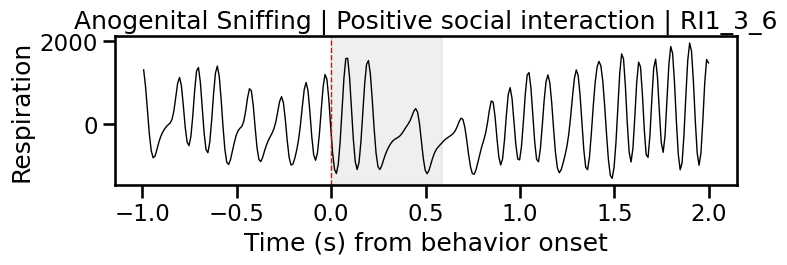

In [ ]:
plot_resp_trace_from_boris_row(pos_agent_df.iloc[0], resp_data)


In [ ]:
def plot_minimal_resp_trace(row, resp_data, pre=2, post=2):
    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    valence = str(row['Valence']).strip().capitalize()  # Normalize casing

    # Choose RGB fill colors for RI1/RI2 style
    color_map = {
        'Positive': (83/255, 161/255, 169/255),     # RI1 color
        'Negative': (169/255, 83/255, 118/255)      # RI2 color
    }
    fill_color = color_map.get(valence, (0.8, 0.8, 0.8))  # fallback gray

    # Check if trial exists
    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    # Get windowed signal
    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data around {start:.2f}s in {trial}.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    # Plot
    plt.figure(figsize=(8, 2))
    plt.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    plt.axvspan(0, stop - start, color=fill_color, alpha=0.3)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)

    # Minimal style
    plt.xticks([])
    plt.yticks([])
    plt.box(False)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_minimal_resp_trace(row, resp_data, pre=2, post=2):
    import matplotlib.pyplot as plt

    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = str(row.get('Behavior', '')).strip().title()
    valence = str(row.get('Valence', '')).strip().capitalize()

    # Check valence mapping
    color_map = {
        'Positive': (83/255, 161/255, 169/255),     # RI1 color
        'Negative': (169/255, 83/255, 118/255)      # RI2 color
    }

    if valence not in color_map:
        print(f"⚠️ Unexpected valence '{valence}', using fallback color.")
    fill_color = color_map.get(valence, (0.8, 0.8, 0.8))

    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    # Get window
    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for window around {start:.2f}s in {trial}.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    # Plot
    plt.figure(figsize=(8, 2))
    plt.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    plt.axvspan(0, stop - start, color=fill_color, alpha=0.4)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)

    # Minimal style
    plt.xticks([])
    plt.yticks([])
    plt.box(False)
    plt.title(f"{behavior} | {valence}", fontsize=10, weight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_minimal_resp_trace(row, resp_data, pre=1, post=1):
    import matplotlib.pyplot as plt

    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = str(row.get('Behavior', '')).strip().title()

    # Robust valence mapping
    valence_raw = str(row.get('Valence', '')).lower()
    if 'positive' in valence_raw:
        valence = 'Positive'
    elif 'negative' in valence_raw:
        valence = 'Negative'
    else:
        valence = 'Unknown'

    color_map = {
        'Positive': (83/255, 161/255, 169/255),
        'Negative': (169/255, 83/255, 118/255)
    }

    if valence not in color_map:
        print(f"⚠️ Unexpected valence '{valence_raw}', using fallback color.")
    fill_color = color_map.get(valence, (0.8, 0.8, 0.8))

    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for window around {start:.2f}s in {trial}.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    plt.figure(figsize=(8, 2))
    plt.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    plt.axvspan(0, stop - start, color=fill_color, alpha=0.4)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)

    plt.xticks([])
    plt.yticks([])
    plt.box(False)
    plt.title(f"{behavior} | {valence}", fontsize=10, weight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_minimal_resp_trace(row, resp_data, pre=1, post=1):
    import matplotlib.pyplot as plt

    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = str(row.get('Behavior', '')).strip().title()

    # Normalize valence
    valence_raw = str(row.get('Valence', '')).lower()
    if 'positive' in valence_raw:
        valence = 'Positive'
    elif 'negative' in valence_raw:
        valence = 'Negative'
    else:
        valence = 'Unknown'

    color_map = {
        'Positive': (83 / 255, 161 / 255, 169 / 255),
        'Negative': (169 / 255, 83 / 255, 118 / 255)
    }
    fill_color = color_map.get(valence, (0.8, 0.8, 0.8))

    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for window around {start:.2f}s in {trial}.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    fig, ax = plt.subplots(figsize=(8, 2))
    ax.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    ax.axvspan(0, stop - start, color=fill_color, alpha=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)

    # Remove ticks and box
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)

    # Add 1 s time scale bar in bottom-left
    ax.plot([0.05, 0.15], [0.05, 0.05], transform=ax.transAxes, color='black', lw=1.5)
    ax.text(0.10, 0.00, '1 s', transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_minimal_resp_trace(row, resp_data, pre=1, post=1, scalebar_sec=0.5):
    import matplotlib.pyplot as plt

    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = str(row.get('Behavior', '')).strip().title()

    # Normalize valence
    valence_raw = str(row.get('Valence', '')).lower()
    if 'positive' in valence_raw:
        valence = 'Positive'
    elif 'negative' in valence_raw:
        valence = 'Negative'
    else:
        valence = 'Unknown'

    color_map = {
        'Positive': (83 / 255, 161 / 255, 169 / 255),
        'Negative': (169 / 255, 83 / 255, 118 / 255)
    }
    fill_color = color_map.get(valence, (0.8, 0.8, 0.8))

    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    # Clip signal
    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for window around {start:.2f}s in {trial}.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    ax.axvspan(0, stop - start, color=fill_color, alpha=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)

    # Clean plot
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)

    # Add accurate scale bar (data-based)
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_start = xmin + 0.05 * (xmax - xmin)
    x_end = x_start + scalebar_sec
    y_bar = ymin + 0.05 * (ymax - ymin)

    ax.plot([x_start, x_end], [y_bar, y_bar], color='black', lw=1.5)
    ax.text((x_start + x_end)/2, y_bar - 0.02 * (ymax - ymin), f'{scalebar_sec:.2f} s',
            ha='center', va='top', fontsize=8)

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_minimal_resp_trace(row, resp_data, pre=1, post=1, scalebar_sec=0.5):
    import matplotlib.pyplot as plt

    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = str(row.get('Behavior', '')).strip().title()

    # Normalize valence
    valence_raw = str(row.get('Valence', '')).lower()
    if 'positive' in valence_raw:
        valence = 'Positive'
    elif 'negative' in valence_raw:
        valence = 'Negative'
    else:
        valence = 'Unknown'

    color_map = {
        'Positive': (83 / 255, 161 / 255, 169 / 255),
        'Negative': (169 / 255, 83 / 255, 118 / 255)
    }
    fill_color = color_map.get(valence, (0.8, 0.8, 0.8))

    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for window around {start:.2f}s in {trial}.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    fig, ax = plt.subplots(figsize=(8, 2))
    ax.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    ax.axvspan(0, stop - start, color=fill_color, alpha=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_start = xmin + 0.05 * (xmax - xmin)
    x_end = x_start + scalebar_sec
    y_bar = ymin + 0.05 * (ymax - ymin)

    ax.plot([x_start, x_end], [y_bar, y_bar], color='black', lw=1.5)
    ax.text((x_start + x_end) / 2, y_bar - 0.02 * (ymax - ymin), f'{scalebar_sec:.2f} s',
            ha='center', va='top', fontsize=8)

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_minimal_resp_trace(row, resp_data, pre=1, post=1, scalebar_sec=0.5):
    import matplotlib.pyplot as plt

    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = str(row.get('Behavior', '')).strip().title()

    # Normalize valence
    valence_raw = str(row.get('Valence', '')).lower()
    if 'positive' in valence_raw:
        valence = 'Positive'
    elif 'negative' in valence_raw:
        valence = 'Negative'
    else:
        valence = 'Unknown'

    color_map = {
        'Positive': (83 / 255, 161 / 255, 169 / 255),
        'Negative': (169 / 255, 83 / 255, 118 / 255)
    }
    fill_color = color_map.get(valence, (0.8, 0.8, 0.8))

    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    # Clip signal
    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for window around {start:.2f}s in {trial}.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    ax.axvspan(0, stop - start, color=fill_color, alpha=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)

    # Force x-axis limits to clipped time window
    ax.set_xlim(clipped_time.min(), clipped_time.max())

    # Remove ticks and box
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)

    # Add scale bar based on exact x-limits
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_start = xmin + 0.05 * (xmax - xmin)
    x_end = x_start + scalebar_sec
    y_bar = ymin + 0.05 * (ymax - ymin)

    ax.plot([x_start, x_end], [y_bar, y_bar], color='black', lw=1.5)
    ax.text((x_start + x_end) / 2, y_bar - 0.02 * (ymax - ymin), f'{scalebar_sec:.2f} s',
            ha='center', va='top', fontsize=8)

    plt.tight_layout()
    plt.show()


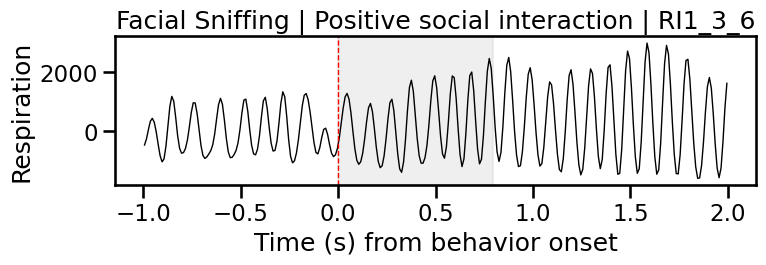

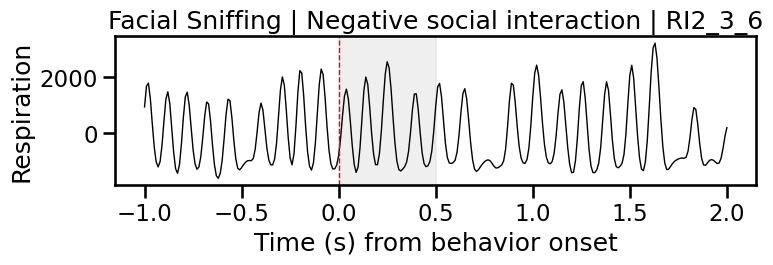

In [ ]:
example_rows = pd.concat([
    pos_agent_df.iloc[[4]],   # 5th row (index 4) of positive agent
    neg_agent_df.iloc[[0]]    # 1st row (index 0) of negative agent
])

for _, row in example_rows.iterrows():
    plot_resp_trace_from_boris_row(row, resp_data)
